# CKN: from Ca²⁺ signalling to redox-responsive proteins

This tutorial follows case study 2 of the
[SKM publication](https://doi.org/10.1016/j.xplc.2024.100920), with the Comprehensive
Knowledge Network (CKN):

> Arabidopsis rosettes were treated with H₂O₂, with or without the Ca²⁺ channel inhibitor
> LaCl₃, and their proteomes compared. Some proteins responded to H₂O₂ only when Ca²⁺
> signalling could take place: *Ca²⁺-dependent redox-responsive* proteins. How could Ca²⁺
> signalling reach them?

Along the way, it shows how to:

- load CKN and filter it by species, tissue and edge reliability (rank),
- add experimental data (logFC and p-values) to the nodes,
- find nodes by MapMan bin, and shortest paths between groups of nodes,
- find minimum cuts,
- translate the network to another species (here potato),
- convert the results to JSON,
- show the results in Cytoscape, with charts of the data on the nodes.

The Cytoscape cells (the last section) need a running Cytoscape; everything else runs
without it.

In [1]:
import json
from collections import Counter
from pathlib import Path

import networkx as nx
import pandas as pd

from skm_tools.annotations import get_nodes_by_mapman
from skm_tools.ckn import ckn_to_networkx, filter_ckn_edges, filter_ckn_nodes, rank_counts
from skm_tools.cuts import get_cutset
from skm_tools.experimental_data import add_experimental_data
from skm_tools.paths import get_paths, path_subgraph
from skm_tools.serialize import graph_to_dict, path_to_dict
from skm_tools.translate import integrate_translation_ckn, load_translation_file

data_dir = Path("data")
output_dir = Path("output")
data_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

# the proteomics data of the case study, from the publication folder of this repository
proteomics_file = Path("../publication/case-study-2/data/merged-proteomics-data.tsv")

## Loading CKN

CKN is downloaded from [skm.nib.si](https://skm.nib.si) the first time, into `data/`
(about 4 MB). Undirected edges (e.g. binding) are added in both directions, so that
directed path searches can use them either way.

In [2]:
ckn = ckn_to_networkx(data_dir / "ckn-edges.tsv.gz", data_dir / "ckn-nodes.tsv.gz")
print(ckn)

DiGraph with 26234 nodes and 898887 edges


Node types are the PSS classes; genes and RNAs also have their TAIR locus type:

In [3]:
Counter(d["node_type"] for _, d in ckn.nodes(data=True))

Counter({'PlantCoding': 24304,
         'PlantNonCoding': 1610,
         'Metabolite': 123,
         'PlantPseudogene': 122,
         'Complex': 49,
         'ForeignCoding': 10,
         'Process': 8,
         'ForeignNonCoding': 3,
         'ForeignAbiotic': 3,
         'ForeignEntity': 2})

In [4]:
ckn.nodes["AT2G38470"]

{'node_type': 'PlantCoding',
 'locus_type': 'protein_coding',
 'species': 'ath',
 'TAIR': 'AT2G38470',
 'display_label': 'WRKY33',
 'short_name': 'WRKY33',
 'synonyms': ['WRKY DNA-binding protein 33',
  'WRKY DNA-BINDING PROTEIN 33',
  'ATWRKY33',
  'WRKY33'],
 'description': 'WRKY DNA-binding protein 33',
 'mapman': ['14.5.7.5.1_RNA biosynthesis.DNA-binding transcriptional regulation.beta-hairpin exposed by alpha/beta-scaffold structure.WRKY transcription factor activity.transcription factor *(WRKY)',
  '26.11.3.2.1_External stimuli response.pathogen.defense mechanisms.WRKY33-dependent plant immunity.transcription factor *(WRKY33)'],
 'note': None,
 'tissue': ['seed', 'root', 'leaf', 'stem', 'flower']}

## Filtering

The experiment is on Arabidopsis leaves, so we keep only Arabidopsis nodes (pathogens and
abiotic stresses are `foreign`; nodes without a species, e.g. metabolites, are kept), and
genes known to be present in leaves (or without tissue information, `not assigned`):

In [5]:
removed = filter_ckn_nodes(ckn, species=["ath"], tissues=["leaf", "not assigned"])
Counter(removed.values())

Removed 1849 nodes from network.


Counter({'wrong tissue type': 1690,
         'isolate': 133,
         'wrong species': 24,
         'complex component removed': 2})

Edges have a *rank*, from 0 (curated, from PSS) to 4 (only predicted). We keep ranks 0 to 2:
experimentally supported interactions.

In [6]:
rank_counts(ckn)
filter_ckn_edges(ckn, keep_edge_ranks=[0, 1, 2])
print(ckn)

rank 0:	 2,416
rank 1:	 33,830
rank 2:	 61,106
rank 3:	 657,126
rank 4:	 67,425


Removed 724551 edges from network.
DiGraph with 12536 nodes and 97352 edges


## The proteomics data

The table has a row per protein (Arabidopsis gene id), with the logFC, p-value and
significance of four comparisons (mock or LaCl₃ pre-treatment; H₂O₂ for 10 or 30 minutes),
and which proteins are Ca²⁺-dependent redox-responsive:

In [7]:
proteomics = pd.read_csv(proteomics_file, sep="\t", index_col=0)
logfc_columns = [c for c in proteomics.columns if c.endswith("log-FC")]
logfc_columns

['Mock|Mock vs Mock|H2O2 (10 min) log-FC',
 'La3+|Mock vs La3+|H2O2 (10 min) log-FC',
 'Mock|Mock vs Mock|H2O2 (30 min) log-FC',
 'La3+|Mock vs La3+|H2O2 (30 min) log-FC']

In [8]:
responsive = proteomics[proteomics["responsiveness"].notna()]
responsive_in_ckn = [p for p in responsive.index if p in ckn]
print(len(responsive), "responsive proteins,", len(responsive_in_ckn), "in the filtered CKN")

59 responsive proteins, 41 in the filtered CKN


<div class="alert alert-info">

**A subset, to keep this tutorial fast.** Searching paths from every Ca²⁺-related gene to
every responsive protein takes several minutes. Here we use only the 10 proteins with the
largest change after 10 minutes of H₂O₂; for the full analysis, use `responsive_in_ckn`.

</div>

In [9]:
mock_10min = "Mock|Mock vs Mock|H2O2 (10 min) log-FC"
targets = (proteomics.loc[responsive_in_ckn, mock_10min].abs()
           .sort_values(ascending=False).index[:10].tolist())
targets

['AT1G45201',
 'AT3G07660',
 'AT1G13750',
 'AT1G29690',
 'AT3G07630',
 'AT3G10340',
 'AT3G53260',
 'AT4G30490',
 'AT2G30520',
 'AT5G01600']

## Ca²⁺-related genes

The path searches start from the genes in MapMan bin 27.8, *Multi-process
regulation. calcium homeostasis* (MapMan4), including its sub-bins:

In [10]:
sources = get_nodes_by_mapman(ckn, "27.8")
print(len(sources), "genes in bin 27.8")

80 genes in bin 27.8


## Shortest paths

For each target, the shortest paths from the sources. With `shortest_overall=True`, only
the paths as short as the shortest from *any* source are kept, so each target is reached
by its closest Ca²⁺-related genes.

In [11]:
paths = get_paths(ckn, sources, targets, shortest_overall=True)
print(len(paths), "paths; edges per path:", dict(Counter(len(p) - 1 for p in paths)))

label = dict(ckn.nodes(data="display_label"))
for p in paths[:5]:
    print(" → ".join(label[n] for n in p))

96 paths; edges per path: {3: 60, 4: 22, 2: 14}
CBL9 → AGL20 → LFY3 → TLL1
CAM4 → AGL8 → LFY3 → TLL1
CAM8 → AGL8 → LFY3 → TLL1
AT3G03000 → TCP14 → LST8-1 → TOR → AT3G07660
AT3G03000 → TIFY8 → LST8-1 → TOR → AT3G07660


In [12]:
paths_net = path_subgraph(paths, ckn)
print(paths_net)

DiGraph with 89 nodes and 119 edges


## Minimum cuts

Which interactions does the Ca²⁺ signal have to pass on its way to the targets? The
minimum cut is the smallest set of edges whose removal disconnects the sources from the
targets. Each edge counts as 1 (`capacity`):

In [13]:
nx.set_edge_attributes(paths_net, 1, "capacity")
cut = get_cutset(sources, targets, paths_net)
[(label[u], label[v]) for u, v in cut]

max_flow = 21


[('KFB01', 'PAL4'),
 ('KFB01', 'PAL2'),
 ('TYRA2', 'ADT2'),
 ('TOR', 'AT3G07660'),
 ('BRL2', 'PAP1'),
 ('PAL1', 'PAL4'),
 ('WRKY33', 'CAD1'),
 ('TTL3', 'RPT2'),
 ('PIF4', 'FER1'),
 ('VDAC1', 'AT4G30490'),
 ('MYB83', 'PAL4'),
 ('HAT22', 'PAP1'),
 ('HAT22', 'AT4G30490'),
 ('MYB4', 'PAL2'),
 ('HB30', 'PAL4'),
 ('ADT5', 'PAL2'),
 ('ERF9', 'PAL4'),
 ('ERF2', 'PAL4'),
 ('REV', 'PAL4'),
 ('EXO70E2', 'AT4G30490'),
 ('LFY3', 'TLL1')]

## Adding the proteomics data

`add_experimental_data` returns a copy of the network with the data of each node as node
attributes; `prefix` keeps the attributes of different comparisons apart:

In [14]:
with_data = paths_net
for column in logfc_columns:
    comparison = column.removesuffix(" log-FC")
    with_data = add_experimental_data(with_data, proteomics, column, f"{comparison} p-value",
                                      prefix=f"{comparison} ")

# the attributes are <prefix>logFC, <prefix>pvalue and <prefix>significant
mock = "Mock|Mock vs Mock|H2O2 (10 min) "
pd.DataFrame.from_dict(dict(with_data.nodes(data=True)), orient="index").loc[
    targets, ["display_label", f"{mock}logFC", f"{mock}pvalue", f"{mock}significant"]
]

,display_label,Mock|Mock vs Mock|H2O2 (10 min) logFC,Mock|Mock vs Mock|H2O2 (10 min) pvalue,Mock|Mock vs Mock|H2O2 (10 min) significant
AT1G45201,TLL1,3.21794,0.00001,True
AT3G07660,AT3G07660,-1.93634,0.00003,True
AT1G13750,PAP1,-1.52586,0.00806,True
AT1G29690,CAD1,-1.37140,0.00259,True
AT3G07630,ADT2,-1.34952,NaN,False
AT3G10340,PAL4,-1.27660,0.03044,True
AT3G53260,PAL2,-1.27660,0.03044,True
AT4G30490,AT4G30490,-1.20606,0.01287,True
AT2G30520,RPT2,-1.20098,0.01067,True
AT5G01600,FER1,-1.16390,NaN,False


## Translating to potato

The SKM translation tables link Arabidopsis genes to their homologues in other species.
`integrate_translation_ckn` replaces each Arabidopsis gene by its potato homologues
(keeping all of them, as translations can be many-to-many), with the edges copied:

In [15]:
potato = load_translation_file("stu", data_dir / "stu-translation.tsv.gz")
potato.head()

,ath_source,potato,symbol_source,filter_criteria,evidence
0,AT1G01020,Soltu.DM.11G003840,ARV1,compara,"FastOMA,OrthoDB,PLAZA,compara,MapMan4_Match"
1,AT1G01030,Soltu.DM.08G005020,NGA3,OrthoDB_FastOMA_RBH_MapMan4,"FastOMA,OrthoDB,RBH,MapMan4_Match"
2,AT1G01030,Soltu.DM.08G005030,NGA3,OrthoDB_FastOMA_RBH_MapMan4,"FastOMA,OrthoDB,RBH,MapMan4_Match"
3,AT1G01030,Soltu.DM.08G030310,NGA3,OrthoDB_FastOMA_RBH_MapMan4,"FastOMA,OrthoDB,RBH,MapMan4_Match"
4,AT1G01040,Soltu.DM.10G000330,DCL1,compara,"FastOMA,OrthoDB,RBH,compara,MapMan4_Match"


In [16]:
paths_net_potato = integrate_translation_ckn(paths_net, potato, t_target_col="potato")
print(paths_net_potato)

MultiDiGraph with 208 nodes and 1321 edges


## Converting to JSON

For other tools (or languages), networks and paths can be converted to plain,
JSON-serialisable data:

In [17]:
with open(output_dir / "ckn-ca-paths.json", "w") as handle:
    json.dump({"network": graph_to_dict(with_data), "paths": path_to_dict(paths)}, handle)

path_to_dict(paths[:2])

{'paths': [['AT5G47100', 'AT2G45660', 'AT5G61850', 'AT1G45201'],
  ['AT1G66410', 'AT5G60910', 'AT5G61850', 'AT1G45201']],
 'lengths': [3, 3]}

## Cytoscape

The rest of this tutorial needs a running Cytoscape, the `cytoscape` extra
(`pip install "skm-tools[cytoscape]"`), and the
[enhancedGraphics](https://apps.cytoscape.org/apps/enhancedgraphics) app for the charts.
We show the path network with the SKM style, the logFC of the four comparisons as a bar
chart on each node, and the cut edges highlighted.

In [18]:
# ci-skip: needs a running Cytoscape
import py4cytoscape as p4c
from IPython.display import Image

from skm_tools import cytoscape_utils as cu

p4c.cytoscape_ping()

'You are connected to Cytoscape!'

In [19]:
# ci-skip: needs a running Cytoscape
suid = cu.load_network(with_data, title="Ca2+ paths", collection="Tutorial: CKN", style="skm")
p4c.layout_network("force-directed", network=suid)

Applied SKM to 13413


{}

One bar per comparison: mock pre-treatment in red, LaCl₃ in blue. The charts go into a
node table column, which a copy of the style shows below the nodes:

In [20]:
# ci-skip: needs a running Cytoscape
colours = ["#E41A1C" if c.startswith("Mock") else "#377EB8" for c in logfc_columns]
charts = cu.chart_column(proteomics.loc[[n for n in with_data if n in proteomics.index]],
                         logfc_columns, colours, value_range=(-3, 3),
                         labels=["mock 10'", "La 10'", "mock 30'", "La 30'"])
p4c.load_table_data(charts.to_frame("logFC chart"), network=suid)

style = cu.copy_style("SKM", "SKM-proteomics", networks=[suid])
cu.show_node_images(style, "logFC chart", size=60)
cu.highlight_edges(cut, "#FF7F00", network=suid)

[('AT1G15670', 'AT3G10340'),
 ('AT1G15670', 'AT3G53260'),
 ('AT1G15710', 'AT3G07630'),
 ('AT1G50030', 'AT3G07660'),
 ('AT2G01950', 'AT1G13750'),
 ('AT2G37040', 'AT3G10340'),
 ('AT2G38470', 'AT1G29690'),
 ('AT2G42580', 'AT2G30520'),
 ('AT2G43010', 'AT5G01600'),
 ('AT3G01280', 'AT4G30490'),
 ('AT3G08500', 'AT3G10340'),
 ('AT4G37790', 'AT1G13750'),
 ('AT4G37790', 'AT4G30490'),
 ('AT4G38620', 'AT3G53260'),
 ('AT5G15210', 'AT3G10340'),
 ('AT5G22630', 'AT3G53260'),
 ('AT5G44210', 'AT3G10340'),
 ('AT5G47220', 'AT3G10340'),
 ('AT5G60690', 'AT3G10340'),
 ('AT5G61010', 'AT4G30490'),
 ('AT5G61850', 'AT1G45201')]

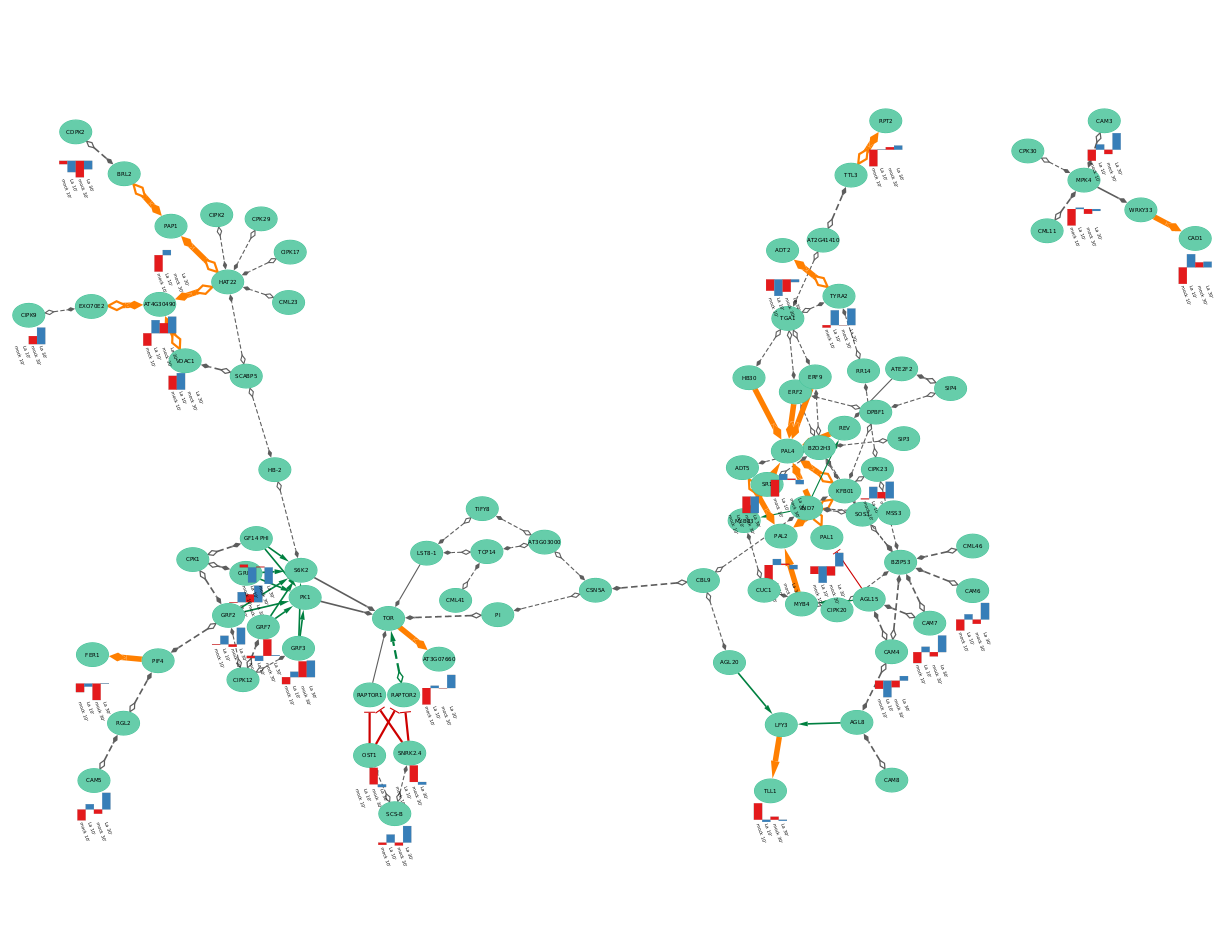

In [21]:
# ci-skip: needs a running Cytoscape
cu.export_network(suid, output_dir / "ckn-ca-paths.png", format="PNG", zoom=150)
Image(output_dir / "ckn-ca-paths.png")